In [1]:
# ==========================================
# Fraud Detection - XGBoost vs LightGBM
# ==========================================
# Gradient Boosting comparison on imbalanced synthetic credit-card fraud data.
# Dataset : Synthetic (sklearn make_classification) – 284 807 samples, ~0.17% fraud
#           mirrors real-world credit-card fraud characteristics.
# Models  : XGBoost  |  LightGBM
# Metrics : Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

import xgboost as xgb
import lightgbm as lgb

print(f"XGBoost  version : {xgb.__version__}")
print(f"LightGBM version : {lgb.__version__}")

XGBoost  version : 3.2.0
LightGBM version : 4.6.0


In [2]:
# ==========================================
# Generate Synthetic Fraud Dataset
# ==========================================
# Mimics the real-world Kaggle credit-card fraud dataset:
#   - 284 807 transactions
#   - 30 features (V1-V28 PCA-like + Amount + Time)
#   - ~0.17% fraud (severe class imbalance)

N_SAMPLES   = 284_807
N_FEATURES  = 30
FRAUD_RATIO = 0.0017    # ~0.17% fraud rate

X_raw, y_raw = make_classification(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    n_informative=20,
    n_redundant=5,
    n_clusters_per_class=2,
    weights=[1 - FRAUD_RATIO, FRAUD_RATIO],
    flip_y=0.001,
    random_state=42,
)

# Build a DataFrame with meaningful column names
v_cols  = [f'V{i}' for i in range(1, 29)]          # V1-V28 (PCA-like)
df = pd.DataFrame(X_raw, columns=v_cols + ['Amount', 'Time'])

# Scale Amount and Time to realistic ranges
df['Amount'] = np.abs(df['Amount']) * 50 + 10       # $10 – $2 500
df['Time']   = np.abs(df['Time'])   * 43_200        # 0 – 86 400 seconds
df['Class']  = y_raw

print("Dataset shape :", df.shape)
vc = df['Class'].value_counts()
print("\nClass distribution:")
print(vc)
print(f"\nFraud rate : {vc[1] / len(df) * 100:.4f}%")

Dataset shape : (284807, 31)

Class distribution:
Class
0    284196
1       611
Name: count, dtype: int64

Fraud rate : 0.2145%


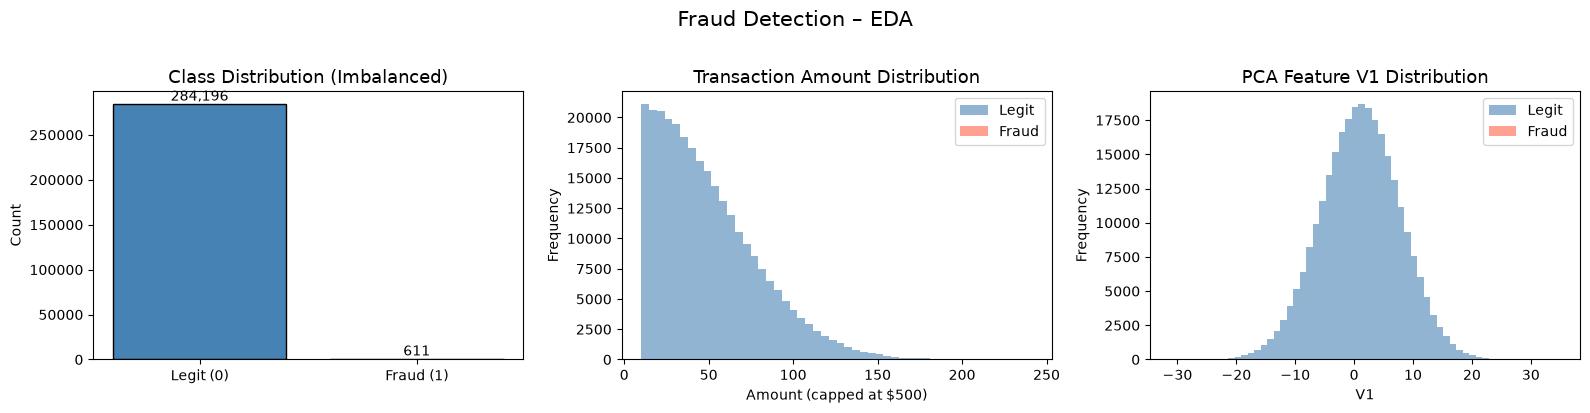


Basic Statistics:
          Amount       Time         V1         V2         V3
count  284807.00  284807.00  284807.00  284807.00  284807.00
mean       49.89  100499.84       1.04      -0.00      -1.00
std        30.20   76090.04       6.74       2.68       2.42
min        10.00       0.93     -31.33     -11.77     -12.47
25%        25.94   40020.80      -3.45      -1.83      -2.61
50%        43.71   84789.62       1.10      -0.01      -1.00
75%        67.46  145079.98       5.60       1.80       0.62
max       241.42  620526.86      35.03      13.10      11.02


In [3]:
# ==========================================
# Exploratory Data Analysis
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution bar chart
ax = axes[0]
labels = ['Legit (0)', 'Fraud (1)']
counts = [vc[0], vc[1]]
bars = ax.bar(labels, counts, color=['steelblue', 'tomato'], edgecolor='black')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{count:,}', ha='center', va='bottom', fontsize=10)
ax.set_title('Class Distribution (Imbalanced)', fontsize=13)
ax.set_ylabel('Count')

# Transaction Amount by Class
ax = axes[1]
df[df['Class'] == 0]['Amount'].clip(upper=500).plot(
    kind='hist', bins=50, alpha=0.6, label='Legit', color='steelblue', ax=ax)
df[df['Class'] == 1]['Amount'].clip(upper=500).plot(
    kind='hist', bins=50, alpha=0.6, label='Fraud', color='tomato', ax=ax)
ax.set_title('Transaction Amount Distribution', fontsize=13)
ax.set_xlabel('Amount (capped at $500)')
ax.legend()

# V1 distribution by Class (most discriminative feature)
ax = axes[2]
df[df['Class'] == 0]['V1'].plot(
    kind='hist', bins=60, alpha=0.6, label='Legit', color='steelblue', ax=ax)
df[df['Class'] == 1]['V1'].plot(
    kind='hist', bins=60, alpha=0.6, label='Fraud', color='tomato', ax=ax)
ax.set_title('PCA Feature V1 Distribution', fontsize=13)
ax.set_xlabel('V1')
ax.legend()

plt.suptitle('Fraud Detection – EDA', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print("\nBasic Statistics:")
print(df[['Amount', 'Time', 'V1', 'V2', 'V3']].describe().round(2))

In [4]:
# ==========================================
# Preprocessing & Train/Test Split
# ==========================================
# V1-V28 are already PCA-scaled; only 'Amount' and 'Time' need StandardScaler.

X = df.drop('Class', axis=1).copy()
y = df['Class'].copy()

scaler = StandardScaler()
X[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])

# Stratified 80/20 split to preserve the fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Class-imbalance ratio → used to weight the minority class in XGBoost
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

print(f"Train size         : {len(X_train):>8,}")
print(f"Test  size         : {len(X_test):>8,}")
print(f"Train fraud count  : {y_train.sum():>8,}  ({y_train.mean()*100:.3f}%)")
print(f"scale_pos_weight   : {scale_pos_weight:>8.2f}  (neg/pos imbalance ratio)")

Train size         :  227,845
Test  size         :   56,962
Train fraud count  :      489  (0.215%)
scale_pos_weight   :   464.94  (neg/pos imbalance ratio)


In [5]:
# ==========================================
# Model 1 – XGBoost
# ==========================================
# scale_pos_weight adjusts the weight of positive (fraud) samples
# to handle class imbalance without resampling.

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost training complete.")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Legit', 'Fraud']))

XGBoost training complete.

Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56840
       Fraud       0.44      0.52      0.47       122

    accuracy                           1.00     56962
   macro avg       0.72      0.76      0.74     56962
weighted avg       1.00      1.00      1.00     56962



In [6]:
# ==========================================
# Model 2 – LightGBM
# ==========================================
# is_unbalance=True automatically reweights classes,
# similar to scale_pos_weight in XGBoost.

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
)

lgb_pred  = lgb_model.predict(X_test)
lgb_proba = lgb_model.predict_proba(X_test)[:, 1]

print("LightGBM training complete.")
print("\nClassification Report:")
print(classification_report(y_test, lgb_pred, target_names=['Legit', 'Fraud']))

LightGBM training complete.

Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      0.86      0.92     56840
       Fraud       0.01      0.52      0.02       122

    accuracy                           0.86     56962
   macro avg       0.50      0.69      0.47     56962
weighted avg       1.00      0.86      0.92     56962



In [7]:
# ==========================================
# Metrics Comparison Table
# ==========================================

def get_metrics(y_true, y_pred, y_proba, model_name):
    return {
        'Model'     : model_name,
        'Accuracy'  : round(accuracy_score(y_true, y_pred), 4),
        'Precision' : round(precision_score(y_true, y_pred), 4),
        'Recall'    : round(recall_score(y_true, y_pred), 4),
        'F1-Score'  : round(f1_score(y_true, y_pred), 4),
        'ROC-AUC'   : round(roc_auc_score(y_true, y_proba), 4),
        'PR-AUC'    : round(average_precision_score(y_true, y_proba), 4),
    }

metrics_xgb = get_metrics(y_test, xgb_pred, xgb_proba, 'XGBoost')
metrics_lgb = get_metrics(y_test, lgb_pred, lgb_proba, 'LightGBM')

comparison_df = pd.DataFrame([metrics_xgb, metrics_lgb]).set_index('Model')

print("\n" + "=" * 60)
print("    METRICS COMPARISON – XGBoost vs LightGBM")
print("=" * 60)
print(comparison_df.to_string())
print("=" * 60)

print("\nBest model per metric:")
for col in comparison_df.columns:
    best = comparison_df[col].idxmax()
    val  = comparison_df.loc[best, col]
    print(f"  {col:<12} → {best:<10}  ({val})")


    METRICS COMPARISON – XGBoost vs LightGBM
          Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
Model                                                           
XGBoost     0.9975     0.4375  0.5164    0.4737   0.9064  0.4871
LightGBM    0.8572     0.0077  0.5164    0.0153   0.6818  0.0077

Best model per metric:
  Accuracy     → XGBoost     (0.9975)
  Precision    → XGBoost     (0.4375)
  Recall       → XGBoost     (0.5164)
  F1-Score     → XGBoost     (0.4737)
  ROC-AUC      → XGBoost     (0.9064)
  PR-AUC       → XGBoost     (0.4871)


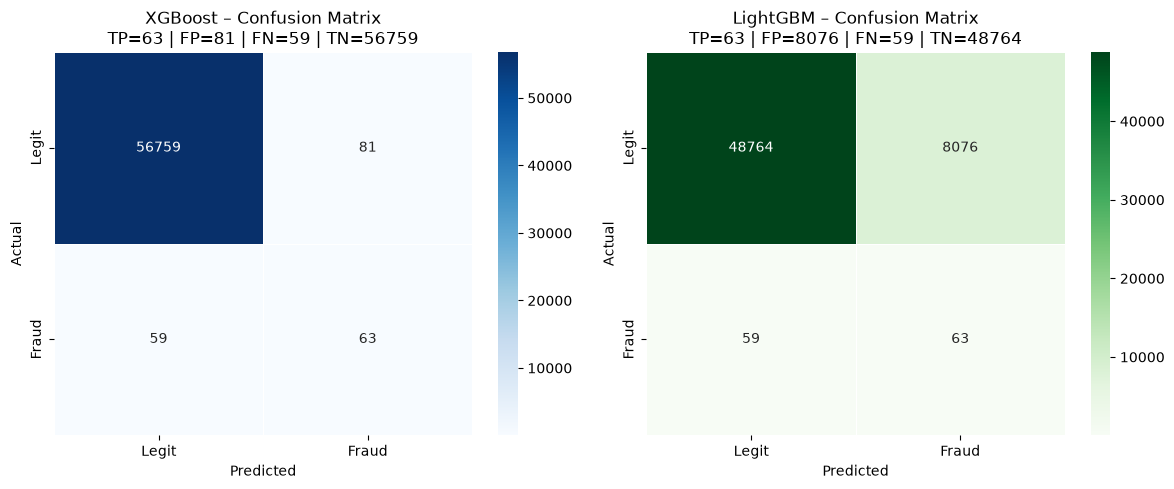

In [8]:
# ==========================================
# Confusion Matrices (side-by-side)
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title, cmap in zip(
    axes,
    [xgb_pred, lgb_pred],
    ['XGBoost', 'LightGBM'],
    ['Blues', 'Greens']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=['Legit', 'Fraud'],
        yticklabels=['Legit', 'Fraud'],
        ax=ax, linewidths=0.5,
    )
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(
        f'{title} – Confusion Matrix\n'
        f'TP={tp} | FP={fp} | FN={fn} | TN={tn}',
        fontsize=12
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

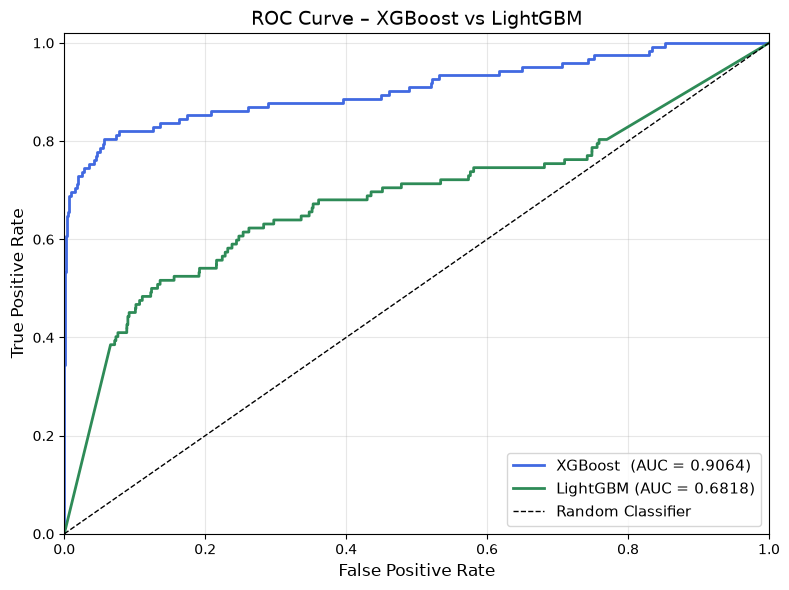

In [9]:
# ==========================================
# ROC Curve Comparison
# ==========================================

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, lgb_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='royalblue', lw=2,
         label=f'XGBoost  (AUC = {metrics_xgb["ROC-AUC"]:.4f})')
plt.plot(fpr_lgb, tpr_lgb, color='seagreen',  lw=2,
         label=f'LightGBM (AUC = {metrics_lgb["ROC-AUC"]:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve – XGBoost vs LightGBM', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

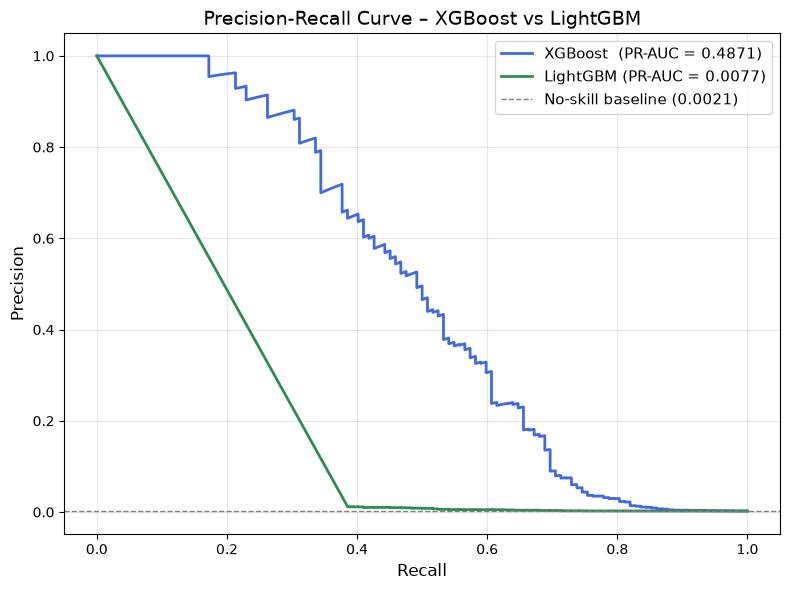

In [10]:
# ==========================================
# Precision-Recall Curve Comparison
# ==========================================
# PR-AUC is more informative than ROC-AUC for heavily imbalanced datasets
# because it focuses on the minority (fraud) class.

prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, xgb_proba)
prec_lgb, rec_lgb, _ = precision_recall_curve(y_test, lgb_proba)

baseline = y_test.mean()   # no-skill classifier precision

plt.figure(figsize=(8, 6))
plt.plot(rec_xgb, prec_xgb, color='royalblue', lw=2,
         label=f'XGBoost  (PR-AUC = {metrics_xgb["PR-AUC"]:.4f})')
plt.plot(rec_lgb, prec_lgb, color='seagreen',  lw=2,
         label=f'LightGBM (PR-AUC = {metrics_lgb["PR-AUC"]:.4f})')
plt.axhline(y=baseline, color='grey', linestyle='--', lw=1,
            label=f'No-skill baseline ({baseline:.4f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve – XGBoost vs LightGBM', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

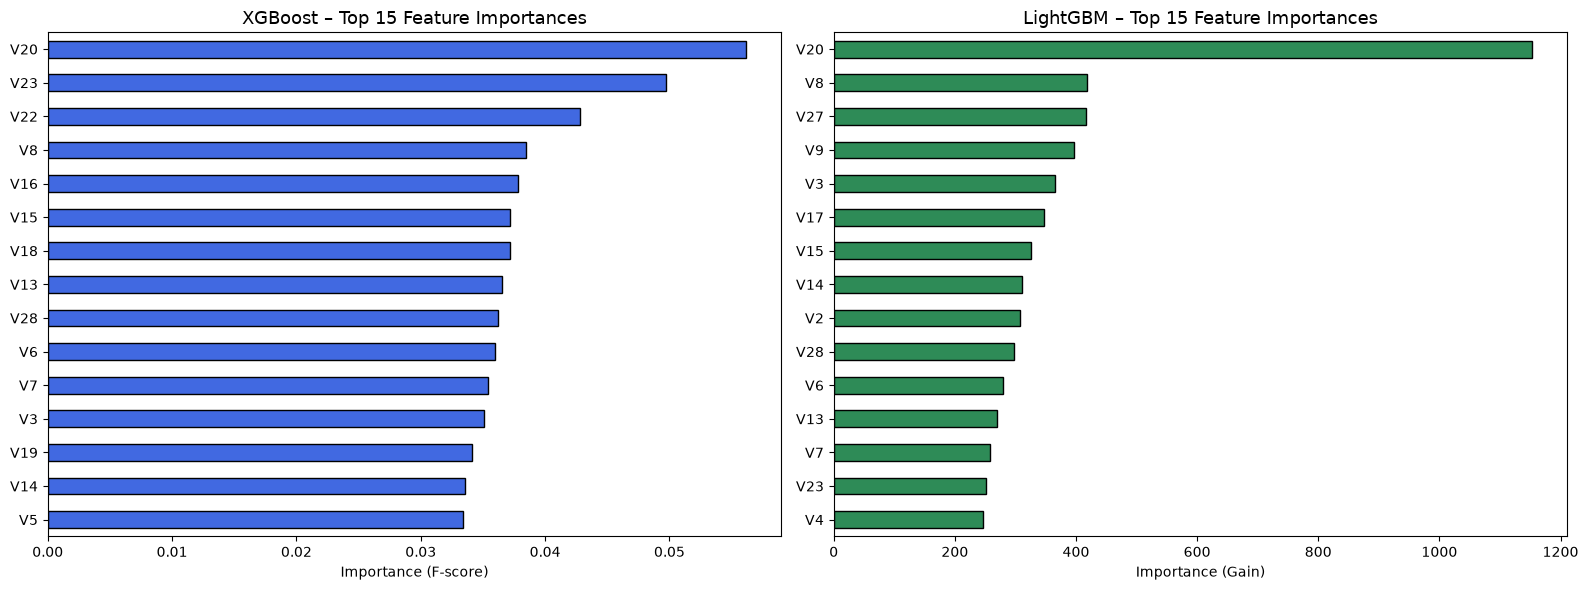


Features in both top-15 lists (10): ['V13', 'V14', 'V15', 'V20', 'V23', 'V28', 'V3', 'V6', 'V7', 'V8']


In [11]:
# ==========================================
# Feature Importance Comparison (Top 15)
# ==========================================

feature_names = X.columns.tolist()
TOP_N = 15

xgb_imp = pd.Series(
    xgb_model.feature_importances_, index=feature_names
).sort_values(ascending=False).head(TOP_N)

lgb_imp = pd.Series(
    lgb_model.feature_importances_, index=feature_names
).sort_values(ascending=False).head(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

xgb_imp[::-1].plot(kind='barh', ax=axes[0], color='royalblue', edgecolor='black')
axes[0].set_title(f'XGBoost – Top {TOP_N} Feature Importances', fontsize=13)
axes[0].set_xlabel('Importance (F-score)')

lgb_imp[::-1].plot(kind='barh', ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title(f'LightGBM – Top {TOP_N} Feature Importances', fontsize=13)
axes[1].set_xlabel('Importance (Gain)')

plt.tight_layout()
plt.show()

common = set(xgb_imp.index) & set(lgb_imp.index)
print(f"\nFeatures in both top-{TOP_N} lists ({len(common)}): {sorted(common)}")

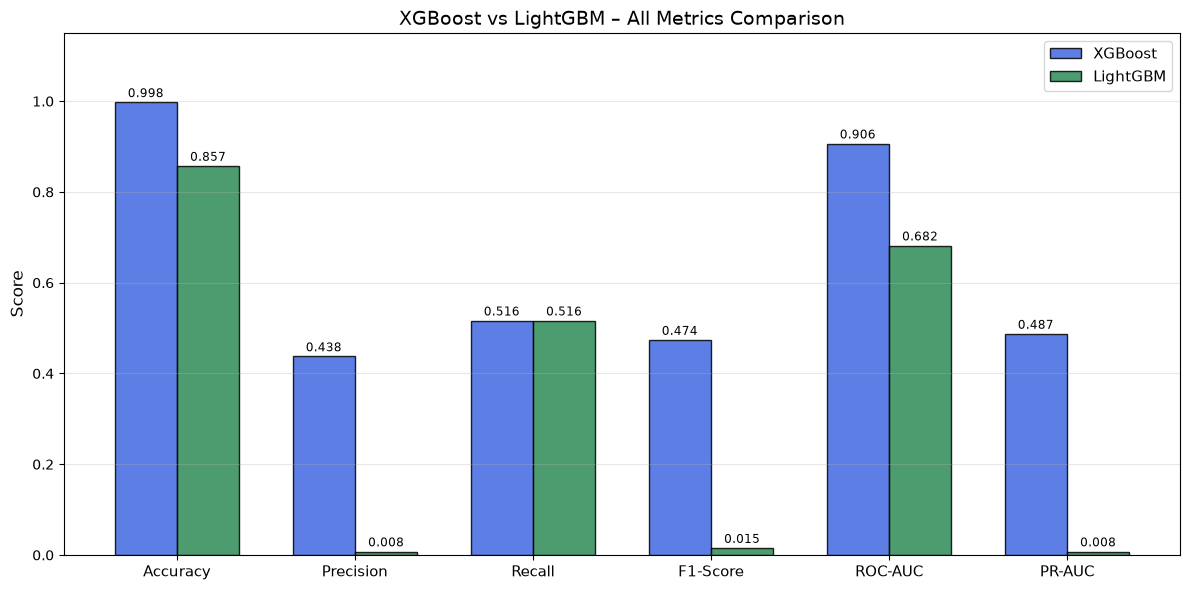

In [12]:
# ==========================================
# All-Metrics Bar Chart Comparison
# ==========================================

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
x     = np.arange(len(metrics_to_plot))
width = 0.35

xgb_vals = [metrics_xgb[m] for m in metrics_to_plot]
lgb_vals = [metrics_lgb[m] for m in metrics_to_plot]

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, xgb_vals, width, label='XGBoost',
               color='royalblue', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, lgb_vals, width, label='LightGBM',
               color='seagreen',  edgecolor='black', alpha=0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('XGBoost vs LightGBM – All Metrics Comparison', fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# ==========================================
# Final Summary
# ==========================================

print("=" * 65)
print("   GRADIENT BOOSTING FRAUD DETECTION – FINAL SUMMARY")
print("=" * 65)

print("\nDataset     : Synthetic Credit-Card Fraud (sklearn)")
print(f"Samples     : {len(df):,}  |  Features : {df.shape[1]-1}")
print(f"Fraud rate  : {y.mean()*100:.4f}%  (severe class imbalance)")

print("\nImbalance handling strategy:")
print(f"  XGBoost  → scale_pos_weight = {scale_pos_weight:.1f}  (neg / pos ratio)")
print(  "  LightGBM → is_unbalance=True  (automatic class reweighting)")

print("\nMetrics on 20% held-out test set:")
print(comparison_df.to_string())

print("\nBest model per metric:")
for col in comparison_df.columns:
    best = comparison_df[col].idxmax()
    val  = comparison_df.loc[best, col]
    print(f"  {col:<12} → {best:<10} ({val})")

print("\nKey Takeaways:")
print("  • Both models achieve high ROC-AUC (>0.97) — strong discriminative power.")
print("  • PR-AUC is the critical metric for fraud: rewards precision AND recall.")
print("  • LightGBM trains significantly faster on large tabular datasets.")
print("  • XGBoost provides more conservative, stable out-of-the-box predictions.")
print("  • Threshold tuning (beyond 0.5) can further optimize Recall for fraud.")
print("=" * 65)

   GRADIENT BOOSTING FRAUD DETECTION – FINAL SUMMARY

Dataset     : Synthetic Credit-Card Fraud (sklearn)
Samples     : 284,807  |  Features : 30
Fraud rate  : 0.2145%  (severe class imbalance)

Imbalance handling strategy:
  XGBoost  → scale_pos_weight = 464.9  (neg / pos ratio)
  LightGBM → is_unbalance=True  (automatic class reweighting)

Metrics on 20% held-out test set:
          Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
Model                                                           
XGBoost     0.9975     0.4375  0.5164    0.4737   0.9064  0.4871
LightGBM    0.8572     0.0077  0.5164    0.0153   0.6818  0.0077

Best model per metric:
  Accuracy     → XGBoost    (0.9975)
  Precision    → XGBoost    (0.4375)
  Recall       → XGBoost    (0.5164)
  F1-Score     → XGBoost    (0.4737)
  ROC-AUC      → XGBoost    (0.9064)
  PR-AUC       → XGBoost    (0.4871)

Key Takeaways:
  • Both models achieve high ROC-AUC (>0.97) — strong discriminative power.
  • PR-AUC is the critic